# Clustering-Benchmark: K-Means · Ward · GMM · HDBSCAN

**Zweck:** Vergleicht vier Clusterverfahren auf denselben HAST-Features
(`data/processed/hast_features.csv`, neu erzeugt nach dem
`full_load_hours`-Fix) und **identischer Vorverarbeitung** wie Notebook
[01_kmeans_stationscluster.ipynb](01_kmeans_stationscluster.ipynb).
Bewertet wird mit Silhouette (immer zusammen mit den Clustergrößen),
Bootstrap-ARI als Stabilitätsmaß und dem Ground-Truth-Join gegen die
Begehungen.

**Eigenständig:** braucht nur `hast_features.csv`, `inspections_tidy.csv`
und `data/raw/Zuordnung.xlsx` (für den BHKW-Ausschluss über die
V-PIN-Spalte).

**Festlegungen vorab (nicht automatisch):** k wird **fest auf 3 gesetzt**
(Begründung in Abschnitt 4), der Zufallsseed ist überall 42. Der
BHKW-Ausschluss ist ein Parameter (Abschnitt 2), weil die
Team-Entscheidung dazu noch aussteht — beide Varianten werden
gerechnet.

## 1 · Setup & Daten laden

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.cluster import AgglomerativeClustering, HDBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.facecolor"] = "white"

ROOT = Path.cwd().resolve()
while not (ROOT / "data" / "processed").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.load_data import _normalize_address  # noqa: E402

FEATURES_PATH = ROOT / "data" / "processed" / "hast_features.csv"
INSPECTIONS_PATH = ROOT / "data" / "processed" / "inspections_tidy.csv"
ZUORDNUNG_PATH = ROOT / "data" / "raw" / "Zuordnung.xlsx"
for path in (FEATURES_PATH, INSPECTIONS_PATH, ZUORDNUNG_PATH):
    if not path.is_file():
        raise FileNotFoundError(f"{path} nicht gefunden")

features_all = pd.read_csv(FEATURES_PATH)
print(f"{len(features_all)} HAST-Profile geladen")
cov = features_all["coverage"]
print(f"coverage: {cov.min():.1%} bis {cov.max():.1%} (Median {cov.median():.1%}) — "
      "Qualitätsdimension, wird mitgeführt, aber nicht als Feature genutzt")
features_all.head()

100 HAST-Profile geladen
coverage: 16.7% bis 98.7% (Median 71.6%) — Qualitätsdimension, wird mitgeführt, aber nicht als Feature genutzt


,rt_mean_winter,rt_p95,dt_mean_loaded,dt_std_loaded,rt_above_50_share_loaded,summer_flow_share,summer_flow_baseline,flow_ceiling_slope_per_month,peak_load_share,p95_load_share,flow_short_cycle_power,idle_share,energy_kwh_year,full_load_hours,Zählernummer,address,anschlusswert_kw,coverage,n_rows,n_hours
0,63.068956,75.9,17.084723,4.837782,0.999885,0.248129,0.0,32.892912,NaN,NaN,0.127965,0.627069,527771.784422,1632.260311,41566330,NaN,NaN,0.732206,23681,32342
1,63.427403,78.6,NaN,NaN,1.000000,0.249361,0.0,51.297490,NaN,NaN,0.128082,0.634686,523113.472063,1482.445397,41566331,NaN,NaN,0.732206,23681,32342
2,63.092601,74.6,NaN,NaN,0.999768,0.243702,0.0,47.918037,NaN,NaN,0.134345,0.618143,547638.005009,1538.728263,41566332,NaN,NaN,0.732144,23679,32342
3,34.293990,53.3,13.347791,3.859154,0.995984,0.000000,0.0,43.687088,NaN,NaN,0.198795,0.989145,24770.477103,36.288422,41628863,NaN,NaN,0.732051,23676,32342
4,41.397956,59.2,NaN,NaN,NaN,0.000000,0.0,0.000000,NaN,NaN,NaN,1.000000,0.000000,0.000000,41704231,NaN,NaN,0.732391,23687,32342


**Was macht der Code?**
- Sucht die Projektwurzel selbst (nach oben, bis `data/processed` auftaucht) und hängt sie an `sys.path` → das Notebook läuft aus `notebooks/` genauso wie aus dem Repo-Root
- Lädt die Feature-Tabelle (100 HAST, erzeugt am 2026-09-22 nach dem `full_load_hours`-Fix) und prüft, dass alle drei Eingabedateien existieren
- `_normalize_address` aus `src/load_data.py` wird erst in Abschnitt 9 gebraucht, steht aber von Anfang an bereit
- `coverage` (Anteil belegter Messstunden je Station) wird nur **berichtet**, nicht als Cluster-Feature — sonst clustern wir Datenqualität statt Betriebsverhalten

## 2 · Parameter: BHKW-Ausschluss

In Notebook 01 fiel Zähler 86792512 als Ausreißer auf; laut `Zuordnung.xlsx`
(V-PIN-Spalte) ist das ein **BHKW**, kein normaler Hausanschluss. Ob BHKWs
im Benchmark bleiben sollen, ist eine offene Team-Entscheidung → Parameter
`EXCLUDE_STATION_TYPES`, beide Varianten werden durchgerechnet.

In [2]:
EXCLUDE_STATION_TYPES = ["BHKW"]  # V-PIN-Werte aus Zuordnung.xlsx; Team-Entscheidung offen

# V-PIN steht nur in den Blättern 2024/2025 (das 2026-Blatt hat die Spalte
# nicht mehr). Ein Zähler, der in irgendeinem Jahr mit einem ausgeschlossenen
# V-PIN läuft, wird ausgeschlossen.
vpin = pd.concat([
    pd.read_excel(ZUORDNUNG_PATH, sheet_name=s, dtype={"V-PIN": str})[["Zählernummer", "V-PIN"]]
    for s in ("2024", "2025")
])
vpin["Zählernummer"] = pd.to_numeric(vpin["Zählernummer"], errors="coerce")
vpin = vpin.dropna().drop_duplicates()
ausgeschlossen = vpin[vpin["V-PIN"].isin(EXCLUDE_STATION_TYPES)].copy()
ausgeschlossen["in_features"] = ausgeschlossen["Zählernummer"].isin(features_all["Zählernummer"])
print(f"V-PIN in {EXCLUDE_STATION_TYPES}: {len(ausgeschlossen)} Einträge in der Zuordnung")
display(ausgeschlossen)

drop_meters = set(ausgeschlossen["Zählernummer"].astype("int64"))
varianten = {
    "mit BHKW": features_all,
    "ohne BHKW": features_all[~features_all["Zählernummer"].isin(drop_meters)].copy(),
}
for name, df in varianten.items():
    print(f"Variante '{name}': {len(df)} HAST")

# Die beiden anderen NB01-Ausreißer (58202380, 66761022) stehen gar nicht in
# der Zuordnung.xlsx -> kein Stations-Typ bekannt, bleiben in beiden Varianten drin.


V-PIN in ['BHKW']: 1 Einträge in der Zuordnung


,Zählernummer,V-PIN,in_features
109,86792512.0,BHKW,True


Variante 'mit BHKW': 100 HAST
Variante 'ohne BHKW': 99 HAST


**Was macht der Code?**
- Liest die V-PIN-Spalte aus beiden Jahresblättern der `Zuordnung.xlsx` (als Text, weil dort neben Zahlen auch „BHKW", „HHS-Kessel I" etc. stehen)
- `EXCLUDE_STATION_TYPES` ist die einzige Stelle, an der Stations-Typen ausgeschlossen werden — Liste leer = keine Filterung
- Baut zwei Feature-Tabellen: **mit BHKW** (alle 100 HAST) und **ohne BHKW**; alles Folgende läuft auf beiden
- Transparent statt still: die ausgeschlossenen Zähler werden als Tabelle gezeigt

## 3 · Vorverarbeitung (identisch zu Notebook 01)

Dieselben 10 Cluster-Features, dieselbe Kette: **Median-Imputation →
Clipping auf 1./99. Perzentil → StandardScaler**. Die Kette wird je
Variante neu gefittet (Scaler-Parameter aus den jeweils 100 bzw. 99
Stationen), damit beide Läufe in sich sauber sind.

In [3]:
CLUSTER_FEATURES = [
    "rt_mean_winter", "dt_mean_loaded", "dt_std_loaded",
    "summer_flow_baseline", "flow_ceiling_slope_per_month",
    "peak_load_share", "p95_load_share", "flow_short_cycle_power",
    "idle_share", "full_load_hours",
]

X_raw = features_all[CLUSTER_FEATURES].replace([np.inf, -np.inf], np.nan)
missing_share = (X_raw.isna().mean() * 100).sort_values(ascending=False)
print("Anteil fehlender Werte je Cluster-Feature (Variante 'mit BHKW'):")
display(missing_share.round(1).to_frame("% fehlend"))


def vorverarbeiten(df):
    """Median-Imputation -> Clipping 1./99. Perzentil -> StandardScaler."""
    raw = df[CLUSTER_FEATURES].replace([np.inf, -np.inf], np.nan)
    imp = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(raw),
                       columns=CLUSTER_FEATURES, index=df.index)
    bounds = imp.quantile([0.01, 0.99])
    clipped = imp.clip(lower=bounds.loc[0.01], upper=bounds.loc[0.99], axis=1)
    return StandardScaler().fit_transform(clipped)


X_varianten = {name: vorverarbeiten(df) for name, df in varianten.items()}
for name, X in X_varianten.items():
    print(f"Variante '{name}': Matrix {X.shape[0]} HAST x {X.shape[1]} Features")

Anteil fehlender Werte je Cluster-Feature (Variante 'mit BHKW'):


,% fehlend
peak_load_share,15.0
p95_load_share,15.0
dt_mean_loaded,6.0
dt_std_loaded,6.0
flow_short_cycle_power,2.0
rt_mean_winter,0.0
summer_flow_baseline,0.0
flow_ceiling_slope_per_month,0.0
idle_share,0.0
full_load_hours,0.0


Variante 'mit BHKW': Matrix 100 HAST x 10 Features
Variante 'ohne BHKW': Matrix 99 HAST x 10 Features


**Was macht der Code?**
- Kuratierte Teilmenge von 10 der 14 Kennzahlen — Begründung wie in Notebook 01: ohne rt_p95/rt_above_50_share_loaded (Dopplung zu rt_mean_winter), ohne summer_flow_share (Zwilling von summer_flow_baseline), ohne energy_kwh_year (Größenmaß würde „groß vs. klein" clustern statt „gesund vs. auffällig")
- `vorverarbeiten()` kapselt die Kette, damit beide Varianten garantiert dasselbe bekommen — nur die Stichprobe für Imputation/Clipping/Scaler unterscheidet sich
- `full_load_hours` steht jetzt auf dem korrigierten Stand (max. 6680 h statt 14689 h vor dem Fix)

## 4 · k-Wahl: Elbow & Silhouette (K-Means)

K-Means kann k nicht selbst bestimmen → Sweep k = 2…8 auf beiden
Varianten. Die Entscheidung wird **im Text begründet und fest gesetzt**,
nicht per `idxmax` über die Silhouette (in Notebook 01 entschieden sich
k-Werte teils um 0,002 — das ist Rauschen, kein Befund).

inertia           silhouette          
variante mit BHKW ohne BHKW   mit BHKW ohne BHKW
k                                               
2         796.800   808.764      0.599     0.208
3         641.862   670.327      0.218     0.206
4         559.261   588.597      0.189     0.160
5         498.604   518.847      0.172     0.171
6         459.060   470.583      0.161     0.169
7         420.054   423.233      0.169     0.185
8         376.078   387.718      0.193     0.182

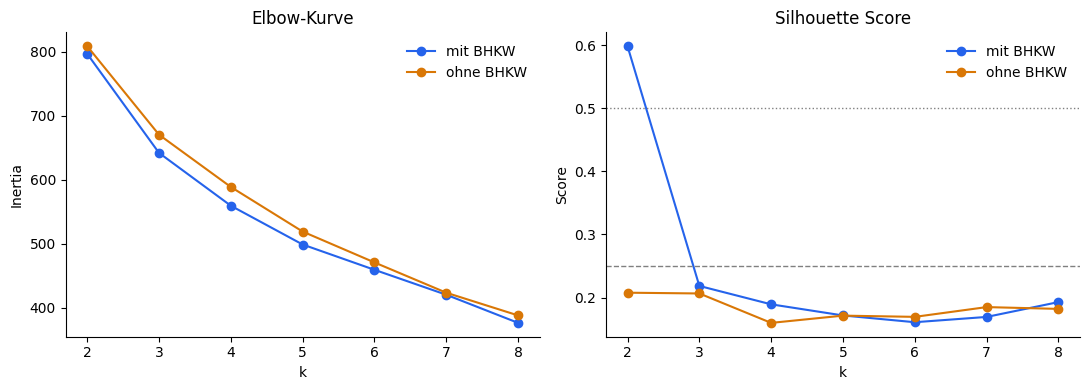

In [4]:
k_values = list(range(2, 9))
sweep_rows = []
for vname, X in X_varianten.items():
    for k in k_values:
        model = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
        sweep_rows.append({
            "variante": vname, "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X, model.labels_),
        })
sweep = pd.DataFrame(sweep_rows)
display(sweep.pivot(index="k", columns="variante", values=["inertia", "silhouette"]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
farben = {"mit BHKW": "#2563EB", "ohne BHKW": "#D97706"}
for vname, grp in sweep.groupby("variante"):
    axes[0].plot(grp["k"], grp["inertia"], marker="o", color=farben[vname], label=vname)
    axes[1].plot(grp["k"], grp["silhouette"], marker="o", color=farben[vname], label=vname)
axes[0].set(title="Elbow-Kurve", xlabel="k", ylabel="Inertia")
axes[1].set(title="Silhouette Score", xlabel="k", ylabel="Score")
axes[1].axhline(0.25, color="grey", lw=1, ls="--")
axes[1].axhline(0.5, color="grey", lw=1, ls=":")
for ax in axes:
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

**Zusammenfassung**

- **Mit BHKW** springt die Silhouette bei k = 2 auf **0,599** — aber die Aufteilung ist **97/3**: das „Cluster" ist das aus Notebook 01 bekannte Ausreißer-Trio (58202380, 66761022, 86792512), keine Betriebsstruktur. Ward zeigt denselben Effekt noch extremer (Abschnitt 5: 0,641 bei 98/2).
- **Ohne BHKW** fällt die k=2-Silhouette auf **0,208** — der hohe Wert steht also maßgeblich auf den Ausreißern. Ward findet auch ohne BHKW noch 97/2 (0,594): die zwei verbleibenden Ausreißer tragen die Trennung allein.
- Ab k = 3 liegen alle K-Means-Werte zwischen **0,16 und 0,22**, durchgehend unter der 0,25-Schwelle → „Grenze durch ein Kontinuum", keine sauberen Typen.
- Elbow: kein sauberer Knick, die Inertia fällt monoton — die Elbow-Methode trägt hier keine Entscheidung.

**Festlegung: K = 3.** k = 2 trennt nur Ausreißer ab (97/3 bzw. 98/2)
— das ist kein operativ nutzbares Clustering. k = 3 ist der
**Konsistenz-Anker** aus der Voranalyse (K-Means, Ward und GMM fanden
unabhängig denselben Kleinst-Cluster, Abschnitt 7) und liefert neben
den Ausreißern eine fachlich lesbare Zwischengruppe mit erhöhtem
Winterrücklauf bei schwacher Spreizung (n = 34, Abschnitt 8). k ≥ 4
fragmentiert die Masse nur weiter (Splitter ab n = 2) ohne
Silhouette-Gewinn.
Einordnungsschwellen für die Silhouette: < 0,25 = „Grenze durch ein
Kontinuum, keine Typen" (Formulierung aus Notebook 01), > 0,5 = klare
räumliche Trennung — die aber bei winzigen Clustern trügerisch sein
kann (Ward-Falle aus NB01: hohe Silhouette bei 97/3-Aufteilung).

In [5]:
K = 3        # fest gesetzt, Begründung im Text oben
SEED = 42    # ein Seed für alle Verfahren und Bootstrap-Läufe


def fit_kmeans(X, k, seed=SEED):
    return KMeans(n_clusters=k, n_init=20, random_state=seed).fit(X).labels_


def fit_ward(X, k, seed=SEED):
    return AgglomerativeClustering(n_clusters=k, linkage="ward").fit(X).labels_


def fit_gmm(X, k, seed=SEED):
    return GaussianMixture(n_components=k, covariance_type="full",
                           n_init=5, random_state=seed).fit(X).predict(X)


FITTER = {"K-Means": fit_kmeans, "Ward": fit_ward, "GMM": fit_gmm}


def groessen(labels):
    counts = pd.Series(labels).value_counts().sort_index()
    return "/".join(str(int(n)) for n in counts)


def sichere_silhouette(X, labels):
    lab = np.asarray(labels)
    if len(np.unique(lab)) < 2:
        return np.nan
    return silhouette_score(X, lab)

**Was macht der Code?**
- K-Means und GMM bekommen denselben `random_state=42`; Ward ist deterministisch (kein Seed nötig)
- GMM mit voller Kovarianz (`covariance_type="full"`): die Cluster dürfen elliptisch statt kugelig sein — passt besser zu korrelierten Features wie rt_mean_winter / dt_mean_loaded
- `groessen()` formatiert die Clustergrößen immer als „97/3"-String: Silhouette wird in diesem Benchmark **nie ohne Größen** zitiert
- `sichere_silhouette()` fängt den Fall ab, dass ein Verfahren nur einen Cluster findet (Silhouette dann undefiniert → NaN statt Absturz)

## 5 · Verfahren × k: Silhouette & Clustergrößen

K-Means, Ward und GMM für k = 2…8. HDBSCAN hat kein k, sondern
`min_cluster_size` — getestet mit 3, 5 und 8. Die Begründung für die
Hauptvariante kommt aus den Daten selbst (siehe Tabelle): **ab
min_cluster_size = 5 degeneriert HDBSCAN vollständig** — alle 100 bzw.
99 Stationen landen im Rauschen, die Dichtestruktur trägt keine
Mindestgröße ab 5. Nur **mcs = 3** findet überhaupt Cluster und wird
daher für Konsistenz-Anker und Export verwendet — zum Preis von rund
einem Fünftel unzugeordneter Stationen. Punkte, die HDBSCAN nicht
zuordnet, gelten als Rauschen (Label −1) und gehen nicht in die
Silhouette ein — ihr Anteil wird ausgewiesen.

In [6]:
rows = []
hdbscan_labels = {}
for vname, X in X_varianten.items():
    for mname, fn in FITTER.items():
        for k in k_values:
            lab = fn(X, k)
            rows.append({"variante": vname, "verfahren": mname, "k": k,
                         "silhouette": sichere_silhouette(X, lab),
                         "größen": groessen(lab)})
    for mcs in (3, 5, 8):
        lab = HDBSCAN(min_cluster_size=mcs).fit(X).labels_
        if mcs == 3:
            hdbscan_labels[vname] = lab
        noise = int((lab == -1).sum())
        ok = lab != -1
        sil = sichere_silhouette(X[ok], lab[ok]) if ok.sum() > 1 else np.nan
        groesse = groessen(lab[ok]) + (f" (+{noise} Rauschen)" if noise else "")
        rows.append({"variante": vname, "verfahren": f"HDBSCAN mcs={mcs}", "k": "-",
                     "silhouette": sil, "größen": groesse})

ergebnis = pd.DataFrame(rows)
display(ergebnis.round(3))

/Users/ivelinayaneva/anaconda3/envs/heating-network/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/Users/ivelinayaneva/anaconda3/envs/heating-network/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/Users/ivelinayaneva/anaconda3/envs/heating-network/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


/Users/ivelinayaneva/anaconda3/envs/heating-network/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/Users/ivelinayaneva/anaconda3/envs/heating-network/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/Users/ivelinayaneva/anaconda3/envs/heating-network/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


,variante,verfahren,k,silhouette,größen
0,mit BHKW,K-Means,2,0.599,97/3
1,mit BHKW,K-Means,3,0.218,34/2/64
2,mit BHKW,K-Means,4,0.189,43/32/2/23
3,mit BHKW,K-Means,5,0.172,15/29/25/29/2
4,mit BHKW,K-Means,6,0.161,27/29/2/16/8/18
5,mit BHKW,K-Means,7,0.169,28/2/15/20/7/23/5
6,mit BHKW,K-Means,8,0.193,22/2/6/5/23/10/14/18
7,mit BHKW,Ward,2,0.641,98/2
8,mit BHKW,Ward,3,0.142,65/2/33
9,mit BHKW,Ward,4,0.171,49/16/33/2


**Zusammenfassung**

- **K-Means k = 3:** Silhouette 0,218 (34/2/64) mit BHKW, 0,206 (61/2/36) ohne — schwach, aber das beste k-Verfahren bei k = 3.
- **Ward k = 3:** 0,142 / 0,181 — schwächstes k-Verfahren bei k = 3, aber höchste Silhouette überhaupt bei k = 2 (0,641 bei 98/2): die klassische Ward-Falle, der Score wird allein vom 2er-Ausreißer-Cluster getragen.
- **GMM k = 3:** 0,174 (3/35/62) / 0,167 (2/36/61); bei k = 2 mit 0,273 (81/19) das einzige Verfahren, das ohne reine Ausreißer-Abspaltung über 0,25 kommt.
- **HDBSCAN:** mcs = 5 und mcs = 8 finden **kein einziges Cluster** (alle Stationen Rauschen) — Negativbefund: die Daten haben keine Dichte-Struktur ab dieser Mindestgröße. Nur mcs = 3 findet 4/72/3 bzw. 4/73/3 mit **19–21 % Rauschen** (Silhouette 0,165/0,171) und wird daher als HDBSCAN-Variante weitergereicht.
- Alle k-fähigen Silhouetten ab k = 3 liegen unter 0,25 → keine der Aufteilungen ist eine belastbare „Typen"-Struktur; die Cluster sind Schnitte durch ein Kontinuum.

## 6 · Stabilität: Bootstrap-ARI

Silhouette misst Geometrie, nicht Stabilität. Hier: 25
Bootstrap-Stichproben (Ziehen mit Zurücklegen), Verfahren neu fitten,
Labels per Nächstes-Zentroid-Regel auf alle Stationen übertragen und
per **Adjusted Rand Index** mit der Referenz-Lösung vergleichen. ARI
1,0 = identische Aufteilung, 0 = Zufallsniveau. Referenzwert aus dem
alten K-Means-Notebook: **0,90** — das war der Wert, der K-Means als
„stabil" ausgewiesen hat, obwohl die Struktur fachlich schwach war.
Ward hat keine `predict`-Methode, die Zentroid-Übertragung ist dort
eine Näherung — wird ehrlich so gekennzeichnet.

In [7]:
def bootstrap_ari(fn, X, k, n_boot=25, seed=SEED):
    """Refit auf n_boot Bootstrap-Stichproben, ARI gegen Referenz-Labels."""
    rng = np.random.default_rng(seed)
    ref = fn(X, k)
    n = len(X)
    aris = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        lab_b = fn(X[idx], k)
        if len(np.unique(lab_b)) < 2:
            continue  # Bootstrap ohne Struktur -> kein verwertbarer Lauf
        klassen = np.unique(lab_b)
        centroids = np.vstack([X[idx][lab_b == c].mean(axis=0) for c in klassen])
        dist = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
        transfer = klassen[dist.argmin(axis=1)]
        aris.append(adjusted_rand_score(ref, transfer))
    return pd.Series({"ari_mean": np.mean(aris), "ari_std": np.std(aris),
                      "ari_min": np.min(aris), "n_laeufe": len(aris)})


stab_rows = []
for vname, X in X_varianten.items():
    for mname, fn in FITTER.items():
        for k in k_values:
            r = bootstrap_ari(fn, X, k)
            stab_rows.append({"variante": vname, "verfahren": mname, "k": k, **r})
    r = bootstrap_ari(lambda Xb, k: HDBSCAN(min_cluster_size=3).fit(Xb).labels_, X, None)
    stab_rows.append({"variante": vname, "verfahren": "HDBSCAN mcs=3", "k": "-", **r})

stabilitaet = pd.DataFrame(stab_rows)
display(stabilitaet.round(3))

/Users/ivelinayaneva/anaconda3/envs/heating-network/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/Users/ivelinayaneva/anaconda3/envs/heating-network/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/Users/ivelinayaneva/anaconda3/envs/heating-network/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/Users/ivelinayaneva/anaconda3/envs/heating-network/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from Fa

/Users/ivelinayaneva/anaconda3/envs/heating-network/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/Users/ivelinayaneva/anaconda3/envs/heating-network/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/Users/ivelinayaneva/anaconda3/envs/heating-network/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/Users/ivelinayaneva/anaconda3/envs/heating-network/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from Fa

,variante,verfahren,k,ari_mean,ari_std,ari_min,n_laeufe
0,mit BHKW,K-Means,2,0.481,0.428,-0.004,25.0
1,mit BHKW,K-Means,3,0.706,0.282,0.039,25.0
2,mit BHKW,K-Means,4,0.484,0.154,0.277,25.0
3,mit BHKW,K-Means,5,0.503,0.122,0.273,25.0
4,mit BHKW,K-Means,6,0.497,0.126,0.263,25.0
5,mit BHKW,K-Means,7,0.507,0.121,0.208,25.0
6,mit BHKW,K-Means,8,0.546,0.110,0.335,25.0
7,mit BHKW,Ward,2,0.536,0.461,-0.027,25.0
8,mit BHKW,Ward,3,0.229,0.167,0.028,25.0
9,mit BHKW,Ward,4,0.377,0.183,0.130,25.0


**Zusammenfassung**

- **K-Means k = 3 ist das stabilste Verfahren:** ARI **0,71** (mit BHKW) bzw. **0,60** (ohne) — aber beide klar unter dem alten Referenzwert 0,90. k = 2 ist trotz guter Silhouette bimodal instabil (Mittel 0,48 bei Std 0,43: manche Bootstrap-Stichproben finden das Ausreißer-Trio, manche nicht).
- **Ward k = 3:** 0,23 / 0,39 — instabil. **GMM k = 3:** 0,46 / 0,38 — mittel.
- **HDBSCAN mcs = 3:** ARI **0,05** in beiden Varianten — praktisch Zufallsniveau. Die dichtebasierte Aufteilung ist nicht nur schwach, sondern bei Neuzeichnung der Stichprobe nicht reproduzierbar.
- Methodik-Einschränkung: Ward und HDBSCAN haben keine `predict`-Methode; die Nächstes-Zentroid-Übertragung ist dort eine Näherung und drückt deren ARI eher nach unten — die Reihenfolge (K-Means vorne) ist trotzdem plausibel.

## 7 · k=3-Konsistenz-Anker

Belastbarster Einzelbefund aus der alten Analyse: Bei k = 3 fanden
K-Means, Ward und GMM **unabhängig denselben Dreier-Cluster**
(Winterrücklauf 59–62 °C, Sommerdurchfluss bis 16 640 l/h,
idle_share ≈ 0 — die Zähler 58202380, 66761022, 86792512). Wenn der
Benchmark belastbar ist, muss sich dieser Anker reproduzieren — mit
und ohne BHKW.

In [8]:
labels_k3 = {v: {m: fn(X_varianten[v], K) for m, fn in FITTER.items()}
             for v in varianten}

for vname in varianten:
    print(f"--- Variante '{vname}': paarweiser ARI zwischen den Verfahren (k={K})")
    ari_tab = pd.DataFrame(index=list(FITTER), columns=list(FITTER), dtype=float)
    for a in FITTER:
        for b in FITTER:
            ari_tab.loc[a, b] = adjusted_rand_score(labels_k3[vname][a], labels_k3[vname][b])
    display(ari_tab.round(3))

TRIO = {58202380, 66761022, 86792512}
anker_rows = []
for vname, df in varianten.items():
    meters = df["Zählernummer"].to_numpy()
    for mname in FITTER:
        lab = labels_k3[vname][mname]
        sizes = pd.Series(lab).value_counts()
        small = sizes.idxmin()
        members = set(meters[lab == small])
        profil = df.loc[lab == small, ["rt_mean_winter", "summer_flow_baseline", "idle_share"]].median()
        anker_rows.append({
            "variante": vname, "verfahren": mname,
            "kleinstes_cluster": int(small), "n": int(sizes.min()),
            "trio_drin": len(members & TRIO),
            "rt_mean_winter": profil["rt_mean_winter"],
            "summer_flow_baseline": profil["summer_flow_baseline"],
            "idle_share": profil["idle_share"],
        })
anker = pd.DataFrame(anker_rows)
display(anker.round(3))

--- Variante 'mit BHKW': paarweiser ARI zwischen den Verfahren (k=3)


,K-Means,Ward,GMM
K-Means,1.000,0.159,0.574
Ward,0.159,1.000,0.146
GMM,0.574,0.146,1.000


--- Variante 'ohne BHKW': paarweiser ARI zwischen den Verfahren (k=3)


,K-Means,Ward,GMM
K-Means,1.000,0.550,0.579
Ward,0.550,1.000,0.493
GMM,0.579,0.493,1.000


,variante,verfahren,kleinstes_cluster,n,trio_drin,rt_mean_winter,summer_flow_baseline,idle_share
0,mit BHKW,K-Means,1,2,2,59.379,12230.0,0.050
1,mit BHKW,Ward,1,2,2,59.379,12230.0,0.050
2,mit BHKW,GMM,0,3,3,60.045,7820.0,0.040
3,ohne BHKW,K-Means,1,2,2,60.297,5045.0,0.033
4,ohne BHKW,Ward,1,2,2,60.297,5045.0,0.033
5,ohne BHKW,GMM,0,2,2,60.297,5045.0,0.033


**Zusammenfassung**

- **Anker bestätigt — mit Einschränkung:** Alle drei Verfahren separieren das Ausreißer-Trio bei k = 3 in **beiden** Varianten als eigenen Kleinst-Cluster (Winterrücklauf-Median 59,4–60,3 °C, Sommerdurchfluss-Median 5 045–12 230 l/h, idle_share ≈ 0,03–0,05 — Deckung mit dem alten Befund 59–62 °C / bis 16 640 l/h / idle_share ≈ 0).
- **Mit BHKW:** GMM findet das volle Trio (n = 3); K-Means und Ward legen nur 58202380 + 86792512 in den Kleinst-Cluster (n = 2) — 66761022 rutscht in die 34er-Zwischengruppe.
- **Ohne BHKW:** identisch bei allen drei Verfahren — n = 2, nämlich {58202380, 66761022}.
- **ABER:** Der paarweise ARI der Gesamtaufteilung liegt bei nur **0,15–0,58**. Die Verfahren sind sich einig über die Ausreißer, aber **nicht** über die Struktur der übrigen ~97 Stationen. Der Anker trägt also die Aussage „diese 2–3 Stationen sind extrem", nicht die Aussage „es gibt drei Betriebstypen".

## 8 · Fachliche Achsen & PCA

Trennen die Verfahren entlang der fernwärmetechnisch relevanten Achse
(Rücklauf/Spreizung: `rt_mean_winter`, `dt_mean_loaded`,
`summer_flow_baseline`)? PCA auf 2 Dimensionen, Ladungen und
Cluster-Mediane in echten Einheiten.

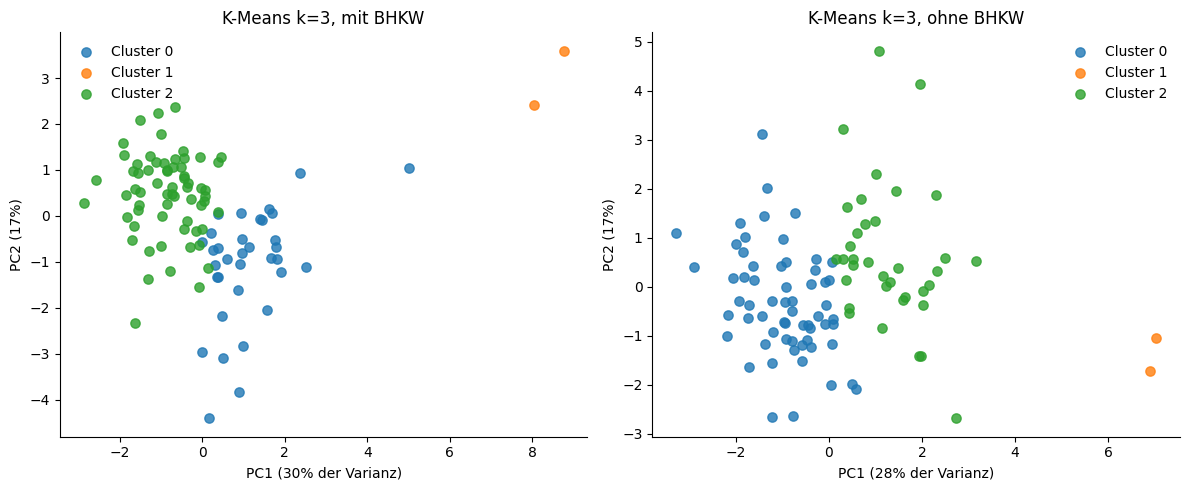

Ladungen (Variante 'mit BHKW'), sortiert nach |PC1|:


,PC1,PC2
full_load_hours,0.46,0.28
summer_flow_baseline,0.45,0.20
rt_mean_winter,0.40,-0.45
idle_share,-0.34,0.01
flow_ceiling_slope_per_month,0.33,0.24
flow_short_cycle_power,-0.29,0.30
dt_mean_loaded,-0.28,0.47
dt_std_loaded,-0.15,-0.20
peak_load_share,-0.13,-0.44
p95_load_share,-0.06,-0.28


--- Variante 'mit BHKW': Cluster-Mediane der fachlichen Achsen (K-Means k=3)


,rt_mean_winter,dt_mean_loaded,summer_flow_baseline,n_hast
cluster,,,,
0,56.33,15.94,35.0,34
1,59.38,15.70,12230.0,2
2,41.67,28.19,0.0,64


--- Variante 'ohne BHKW': Cluster-Mediane der fachlichen Achsen (K-Means k=3)


,rt_mean_winter,dt_mean_loaded,summer_flow_baseline,n_hast
cluster,,,,
0,41.4,28.49,0.0,61
1,60.3,13.29,5045.0,2
2,54.6,17.08,35.0,36


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
palette = plt.cm.tab10.colors
for ax, (vname, X) in zip(axes, X_varianten.items()):
    pca = PCA(n_components=2, random_state=SEED)
    coords = pca.fit_transform(X)
    ev = pca.explained_variance_ratio_
    for c in sorted(set(labels_k3[vname]["K-Means"])):
        mask = labels_k3[vname]["K-Means"] == c
        ax.scatter(coords[mask, 0], coords[mask, 1], s=45, alpha=0.8,
                   color=palette[c % len(palette)], label=f"Cluster {c}")
    ax.set(title=f"K-Means k={K}, {vname}",
           xlabel=f"PC1 ({ev[0]:.0%} der Varianz)", ylabel=f"PC2 ({ev[1]:.0%})")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

pca = PCA(n_components=2, random_state=SEED).fit(X_varianten["mit BHKW"])
loadings = pd.DataFrame(pca.components_.T, index=CLUSTER_FEATURES, columns=["PC1", "PC2"])
print("Ladungen (Variante 'mit BHKW'), sortiert nach |PC1|:")
display(loadings.reindex(loadings["PC1"].abs().sort_values(ascending=False).index).round(2))

achsen = ["rt_mean_winter", "dt_mean_loaded", "summer_flow_baseline"]
for vname, df in varianten.items():
    prof = df.assign(cluster=labels_k3[vname]["K-Means"]).groupby("cluster")[achsen].median()
    prof["n_hast"] = pd.Series(labels_k3[vname]["K-Means"]).value_counts().sort_index()
    print(f"--- Variante '{vname}': Cluster-Mediane der fachlichen Achsen (K-Means k={K})")
    display(prof.round(2))

**Zusammenfassung**

- Zwei PCA-Dimensionen erfassen nur **47,0 %** der Varianz (mit BHKW; ohne: 45,3 %) — die Ebene ist eine grobe Projektion, keine vollständige Sicht.
- PC1 wird getrieben von `full_load_hours` (0,46), `summer_flow_baseline` (0,45) und `rt_mean_winter` (0,40) — die **fachliche Rücklauf-/Spreizungs-Achse ist die Hauptstreurichtung**, genau wie in Notebook 01.
- Die k=3-Cluster-Mediane (K-Means, mit BHKW) lesen sich fachlich sauber: Cluster 2 (n = 64) = unauffällig (Rücklauf 41,7 °C, ΔT 28,2 K, kein Sommerdurchfluss); Cluster 0 (n = 34) = **erhöhter Winterrücklauf 56,3 °C bei ΔT 15,9 K** — die schwach-gespreizte Zwischengruppe; Cluster 1 (n = 2) = Ausreißer (Rücklauf 59,4 °C, Sommerdurchfluss 12 230 l/h).
- Die Verfahren trennen also durchaus entlang der fachlich richtigen Achse — das Problem ist nicht die Richtung, sondern dass die Übergänge fließend sind (Silhouette < 0,25).

## 9 · Ground Truth: Begehungen je Cluster

Join über die normalisierte Adresse (`_normalize_address` aus
`src/load_data.py`, wie gehabt): `inspections_tidy.csv` liefert je
Adresse, ob mindestens eine Maßnahme dokumentiert wurde (`n_actions` >
0). Pro Cluster: Anteil mit Maßnahme, Fisher-Test (Cluster vs. Rest,
Label „Maßnahme ja/nein") und Mann-Whitney-Test auf `n_actions`.
**Basisrate beachten:** ein fast konstantes Label kann nichts trennen
— das ist ein methodischer Befund, kein Modellfehler. Cluster, die im
Join gar nicht vertreten sind, werden benannt statt gerechnet.

In [10]:
insp = pd.read_csv(INSPECTIONS_PATH)
gt = insp.groupby("address_norm").agg(
    n_begehungen=("address_norm", "size"),
    n_actions=("n_actions", "sum"),
).reset_index()
gt["massnahme"] = gt["n_actions"] > 0

gt_joins = {}
for vname, df in varianten.items():
    j = df.copy()
    j["address_norm"] = j["address"].apply(_normalize_address)
    j = j.merge(gt, on="address_norm", how="inner")
    gt_joins[vname] = j
    rate = j["massnahme"].mean()
    print(f"Variante '{vname}': {len(j)} Stationen im GT-Join, "
          f"Basisrate 'mind. eine Maßnahme' = {rate:.0%}")


def gt_tabelle(vname, mname, labels):
    df = varianten[vname]
    j = gt_joins[vname].copy()
    lab_series = pd.Series(labels, index=df["Zählernummer"].to_numpy())
    j["cluster"] = j["Zählernummer"].map(lab_series)
    rows = []
    for c in sorted(set(labels)):
        a = j[j["cluster"] == c]
        b = j[j["cluster"] != c]
        n_total = int((np.asarray(labels) == c).sum())
        if len(a) == 0 or len(b) == 0:
            rows.append({"cluster": int(c), "n_hast": n_total, "n_im_join": len(a),
                         "anteil_massnahme": np.nan, "fisher_p": np.nan, "mwu_p": np.nan})
            continue
        tabelle = [[int(a["massnahme"].sum()), int((~a["massnahme"]).sum())],
                   [int(b["massnahme"].sum()), int((~b["massnahme"]).sum())]]
        p_f = stats.fisher_exact(tabelle)[1]
        p_u = stats.mannwhitneyu(a["n_actions"], b["n_actions"]).pvalue
        rows.append({"cluster": int(c), "n_hast": n_total, "n_im_join": len(a),
                     "anteil_massnahme": a["massnahme"].mean(),
                     "fisher_p": p_f, "mwu_p": p_u})
    return pd.DataFrame(rows)


gt_ergebnisse = {}
for vname in varianten:
    for mname in FITTER:
        tab = gt_tabelle(vname, mname, labels_k3[vname][mname])
        gt_ergebnisse[(vname, mname)] = tab
        print(f"--- Variante '{vname}', {mname} (k={K})")
        display(tab.round(3))

Variante 'mit BHKW': 55 Stationen im GT-Join, Basisrate 'mind. eine Maßnahme' = 80%
Variante 'ohne BHKW': 55 Stationen im GT-Join, Basisrate 'mind. eine Maßnahme' = 80%
--- Variante 'mit BHKW', K-Means (k=3)


,cluster,n_hast,n_im_join,anteil_massnahme,fisher_p,mwu_p
0,0,34,15,0.8,1.0,0.657
1,1,2,0,NaN,NaN,NaN
2,2,64,40,0.8,1.0,0.657


--- Variante 'mit BHKW', Ward (k=3)


,cluster,n_hast,n_im_join,anteil_massnahme,fisher_p,mwu_p
0,0,65,36,0.778,0.73,0.187
1,1,2,0,NaN,NaN,NaN
2,2,33,19,0.842,0.73,0.187


--- Variante 'mit BHKW', GMM (k=3)


...

,cluster,n_hast,n_im_join,anteil_massnahme,fisher_p,mwu_p
0,0,61,37,0.811,1.0,0.757
1,1,2,0,NaN,NaN,NaN
2,2,36,18,0.778,1.0,0.757


--- Variante 'ohne BHKW', Ward (k=3)

,cluster,n_hast,n_im_join,anteil_massnahme,fisher_p,mwu_p
0,0,41,24,0.750,0.505,0.541
1,1,2,0,NaN,NaN,NaN
2,2,56,31,0.839,0.505,0.541


--- Variante 'ohne BHKW', GMM (k=3)


,cluster,n_hast,n_im_join,anteil_massnahme,fisher_p,mwu_p
0,0,2,0,NaN,NaN,NaN
1,1,36,18,0.722,0.473,0.568
2,2,61,37,0.838,0.473,0.568


**Zusammenfassung**

- Der Join trifft **55 verschiedene Stationen** (58 Zeilen vor der Deduplikation — drei Stationen wurden zweimal begangen); Basisrate „mind. eine Maßnahme" = **80 %** in beiden Varianten (der BHKW 86792512 steht nicht in den Begehungsdaten, der Ausschluss ändert am Join nichts).
- **Kein Cluster unterscheidet sich signifikant vom Rest:** Fisher p ≥ 0,47, Mann-Whitney p ≥ 0,19 — über alle Verfahren und beide Varianten. Die Anteile mit Maßnahme liegen bei 72–84 %, also um die Basisrate herum.
- Der auffälligste Befund ist **nicht testbar**: der Ausreißer-Kleinst-Cluster (n = 2–3) hat **0 Stationen im Join** — 58202380, 66761022 und 86792512 wurden nicht begangen bzw. sind nicht zuordenbar. In der Tabelle steht dort bewusst NaN statt eines p-Werts.
- Methodischer Befund (wie schon beim ML-Klassifikator): Bei einer Basisrate von 80 % ist das Label fast konstant — selbst ein perfektes Clustering könnte daran kaum etwas trennen. Die Label-Qualität bleibt der Flaschenhals.

## 10 · Ergebnisse speichern

In [11]:
out_path = ROOT / "data" / "processed" / "cluster_benchmark.csv"
out = features_all[["Zählernummer", "address", "coverage"]].copy()
for vname, df in varianten.items():
    meters = df["Zählernummer"].to_numpy()
    suffix = vname.replace(" ", "_")
    for mname in FITTER:
        spalte = f"cluster_{mname.lower().replace('-', '')}_{suffix}"
        out[spalte] = out["Zählernummer"].map(pd.Series(labels_k3[vname][mname], index=meters))
    spalte = f"cluster_hdbscan_{suffix}"
    out[spalte] = out["Zählernummer"].map(pd.Series(hdbscan_labels[vname], index=meters))
out.to_csv(out_path, index=False)

# Lauf-Kontext: ohne k, Seed und Varianten-Definition lässt sich später nicht
# rekonstruieren, unter welchen Annahmen die Zuordnung entstanden ist.
meta = {
    "erzeugt": pd.Timestamp.now().isoformat(timespec="seconds"),
    "quelle": str(FEATURES_PATH.relative_to(ROOT)),
    "k": K,
    "random_state": SEED,
    "vorverarbeitung": "Median-Imputation -> Clipping 1./99. Perzentil -> StandardScaler (je Variante gefittet)",
    "cluster_features": CLUSTER_FEATURES,
    "exclude_station_types": EXCLUDE_STATION_TYPES,
    "ausgeschlossene_zaehler": sorted(int(m) for m in drop_meters),
    "hdbscan_min_cluster_size": 3,
    "bootstrap": {"n_boot": 25, "methode": "Refit auf Stichprobe, Nächstes-Zentroid-Übertragung"},
    "varianten": {},
}
for vname in varianten:
    vmeta = {"n_hast": int(len(varianten[vname])), "verfahren": {}}
    for mname in FITTER:
        lab = labels_k3[vname][mname]
        sil_row = ergebnis[(ergebnis["variante"] == vname) &
                           (ergebnis["verfahren"] == mname) &
                           (ergebnis["k"] == K)]
        stab_row = stabilitaet[(stabilitaet["variante"] == vname) &
                               (stabilitaet["verfahren"] == mname) &
                               (stabilitaet["k"] == K)]
        vmeta["verfahren"][mname] = {
            "silhouette": round(float(sil_row["silhouette"].iloc[0]), 4),
            "clustergroessen": groessen(lab),
            "bootstrap_ari_mean": round(float(stab_row["ari_mean"].iloc[0]), 4),
        }
    lab = hdbscan_labels[vname]
    ok = lab != -1
    stab_row = stabilitaet[(stabilitaet["variante"] == vname) &
                           (stabilitaet["verfahren"] == "HDBSCAN mcs=3")]
    vmeta["verfahren"]["HDBSCAN"] = {
        "silhouette": round(float(sichere_silhouette(X_varianten[vname][ok], lab[ok])), 4),
        "clustergroessen": groessen(lab[ok]) + f" (+{int((~ok).sum())} Rauschen)",
        "bootstrap_ari_mean": round(float(stab_row["ari_mean"].iloc[0]), 4),
    }
    meta["varianten"][vname] = vmeta

meta_path = out_path.with_suffix(".json")
meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Cluster-Zuordnungen -> {out_path}")
print(f"Lauf-Kontext        -> {meta_path}")

Cluster-Zuordnungen -> /Users/ivelinayaneva/Downloads/projektseminar.worktrees/project-analysis-unsupervised-learning/data/processed/cluster_benchmark.csv
Lauf-Kontext        -> /Users/ivelinayaneva/Downloads/projektseminar.worktrees/project-analysis-unsupervised-learning/data/processed/cluster_benchmark.json


**Was macht der Code?**
- Schreibt eine Zeile je HAST mit den Clusterzuordnungen aller vier Verfahren × beider BHKW-Varianten nach `data/processed/cluster_benchmark.csv` — Rauschen bei HDBSCAN steht als −1 in der Datei
- `cluster_benchmark.json` daneben: Verfahren, k, Silhouette, Größen, Bootstrap-ARI, Seed, BHKW-Variante — damit ist der Lauf reproduzierbar, ohne das Notebook erneut zu rechnen

## Zusammenfassung & Bewertung

### Ergebnis (Lauf 2026-09-22, Features nach dem `full_load_hours`-Fix)

| Verfahren | k | Silhouette (mit / ohne BHKW) | Größen (mit / ohne) | Bootstrap-ARI (mit / ohne) |
|---|---|---|---|---|
| K-Means | 2 | 0,599 / 0,208 | 97/3 · 37/62 | 0,48 / 0,36 |
| **K-Means** | **3** | **0,218 / 0,206** | **34/2/64 · 61/2/36** | **0,71 / 0,60** |
| Ward | 2 | 0,641 / 0,594 | 98/2 · 97/2 | 0,54 / 0,56 |
| Ward | 3 | 0,142 / 0,181 | 65/2/33 · 41/2/56 | 0,23 / 0,39 |
| GMM | 3 | 0,174 / 0,167 | 3/35/62 · 2/36/61 | 0,46 / 0,38 |
| HDBSCAN mcs=3 | – | 0,165 / 0,171 | 4/72/3 · 4/73/3 (+21/+19 Rauschen) | 0,05 / 0,05 |
| HDBSCAN mcs=5/8 | – | – | alles Rauschen | – |

k ≥ 4 wurde für alle Verfahren gerechnet (Tabellen in Abschnitt 5/6),
bringt aber nur Fragmentierung ohne Silhouette-Gewinn.

### Was ist belastbar?

1. **Das Ausreißer-Trio ist der robusteste Befund des Benchmarks.**
   K-Means, Ward und GMM separieren {58202380, 66761022, 86792512} bei
   k = 3 in beiden BHKW-Varianten als eigenen Kleinst-Cluster
   (Winterrücklauf ≈ 60 °C, Sommerdurchfluss 5 000–16 600 l/h,
   idle_share ≈ 0). Das reproduziert den Konsistenz-Anker aus der
   Voranalyse nach dem Feature-Fix.
2. **Die Trennungsachse ist fachlich richtig:** PC1 = Rücklauf /
   Sommerdurchfluss / Vollbenutzungsstunden; die k=3-Zwischengruppe
   (n = 34) mit Rücklauf 56,3 °C bei ΔT 15,9 K ist die fernwärmetechnisch
   interessante „schwach gespreizte" Gruppe.
3. **K-Means k = 3 ist das stabilste Verfahren** (Bootstrap-ARI 0,71 /
   0,60) — aber deutlich unter dem alten Referenzwert 0,90.

### Was ist schwach oder negativ?

- **Keine belastbare Cluster-Struktur jenseits der Ausreißer:** alle
  Silhouetten ab k = 3 liegen unter 0,25 — Schnitte durch ein Kontinuum,
  keine Typen. Die hohen k=2-Scores (0,60/0,64) sind die Ward-Falle:
  getragen von 2–3 Ausreißern, ohne BHKW bricht die K-Means-Silhouette
  bei k = 2 auf 0,21 ein.
- **Die Verfahren sind sich nur über die Ausreißer einig** (paarweiser
  ARI der Gesamtaufteilung 0,15–0,58) — die Struktur der Masse ist
  verfahrensabhängig, also artefaktanfällig.
- **HDBSCAN degeneriert ab min_cluster_size = 5 vollständig** (alles
  Rauschen); nur mcs = 3 findet Cluster, lässt aber ~20 % der Stationen
  unzugeordnet. Dichtebasiertes Clustering trägt auf diesen Features
  nicht.
- **Ground Truth trennt nichts:** kein Cluster signifikant
  maßnahmenreicher (Fisher p ≥ 0,47, MWU p ≥ 0,19), Basisrate 80 % —
  und der interessanteste Cluster (die Ausreißer) ist in den
  Begehungsdaten gar nicht vertreten. Die Label-Lücke für genau die
  auffälligsten Stationen ist der kritischste offene Punkt.

### Konsequenz

Auf den Stationsprofilen über die Gesamthistorie gibt es keine
belastbaren Betriebstypen — der nächste Hebel ist die **zeitliche
Auflösung** (14-Tage-Zustandsfenster, `src/window_features.py`,
Roadmap-Punkt 3/4): Cluster-Wanderung um die Begehungen statt ein
statisches Profil. Dafür liefert `cluster_benchmark.csv` die Referenz-
Zuordnungen. Zwei Entscheidungen bleiben offen (Team): BHKW-Ausschluss
(der Benchmark zeigt: ändert die Ausreißer-Trennung, nicht die
Gesamtaussage) und die fachliche Prüfung der drei Ausreißer-Zähler,
die weder in der Zuordnung (58202380, 66761022) noch in den
Begehungsdaten (alle drei) abgedeckt sind.